# 03 · Demanda por hora del día

**TPO Ciencia de Datos · ¿Dónde faltan cajeros Link en CABA?**

Los cajeros no se usan igual a toda hora. Con los molinetes del subte (SBASE, año 2025 completo, 335 días con datos)
miramos **a qué hora pasa la gente por cada zona**. Como los molinetes cuentan **entradas**, la forma de la curva dice
qué tipo de lugar es cada estación:

- si la gente entra sobre todo **a la mañana**, está saliendo de su casa → estación de **origen** (barrio residencial);
- si entra sobre todo **a la tarde**, está volviendo del trabajo o del estudio → estación de **destino**.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import estilo as e, features as f, horario as ho, modelos as m

e.mpl_estilo()
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
FIG = RAIZ / "docs/figuras"; FIG.mkdir(parents=True, exist_ok=True)
PROC = RAIZ / "data/processed"
ORIGEN, DESTINO = "#1baf7a", "#4a3aa7"

largo = ho.perfiles_estaciones()
curva = ho.curva_red(largo)
print(f"{largo[['linea', 'estacion']].drop_duplicates().shape[0]} estaciones · "
      f"{e.num_es(curva['habil'].sum())} entradas en un día hábil promedio · {e.num_es(curva['fin_de_semana'].sum())} en un día de fin de semana")

90 estaciones · 690.863 entradas en un día hábil promedio · 263.345 en un día de fin de semana


## 1. La curva de toda la red

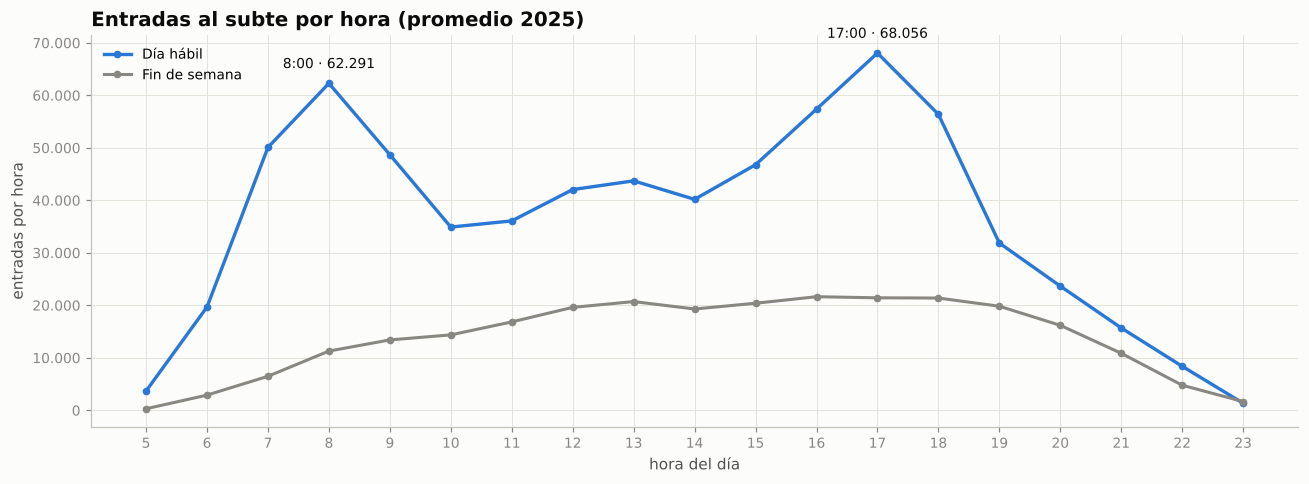

In [2]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(curva.index, curva["habil"], color=e.LINK, linewidth=2.2, marker="o", markersize=4, label="Día hábil")
ax.plot(curva.index, curva["fin_de_semana"], color=e.TINTA_SUAVE, linewidth=2, marker="o", markersize=4, label="Fin de semana")
for h in [curva.loc[5:11, "habil"].idxmax(), curva.loc[14:20, "habil"].idxmax()]:
    v = curva.loc[h, "habil"]
    ax.annotate(f"{h}:00 · {e.num_es(v)}", (h, v), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=9, color=e.TINTA)
ax.set(title="Entradas al subte por hora (promedio 2025)", xlabel="hora del día", ylabel="entradas por hora", xticks=range(5, 24))
ax.legend(loc="upper left"); e.ejes_es(ax, y=0); fig.tight_layout(); fig.savefig(FIG / "horario_curva_red.png"); plt.show()


**Lectura.** Un día hábil promedio entran 690.863 personas al subte, con dos picos: **8:00** a la mañana y
**17:00** a la tarde. Las cuatro horas pico (7, 8, 17 y 18 h) concentran el 34 % de las entradas del
día. El fin de semana la curva es plana y el volumen cae al 38 % del de un día hábil.

## 2. Cada estación tiene su curva

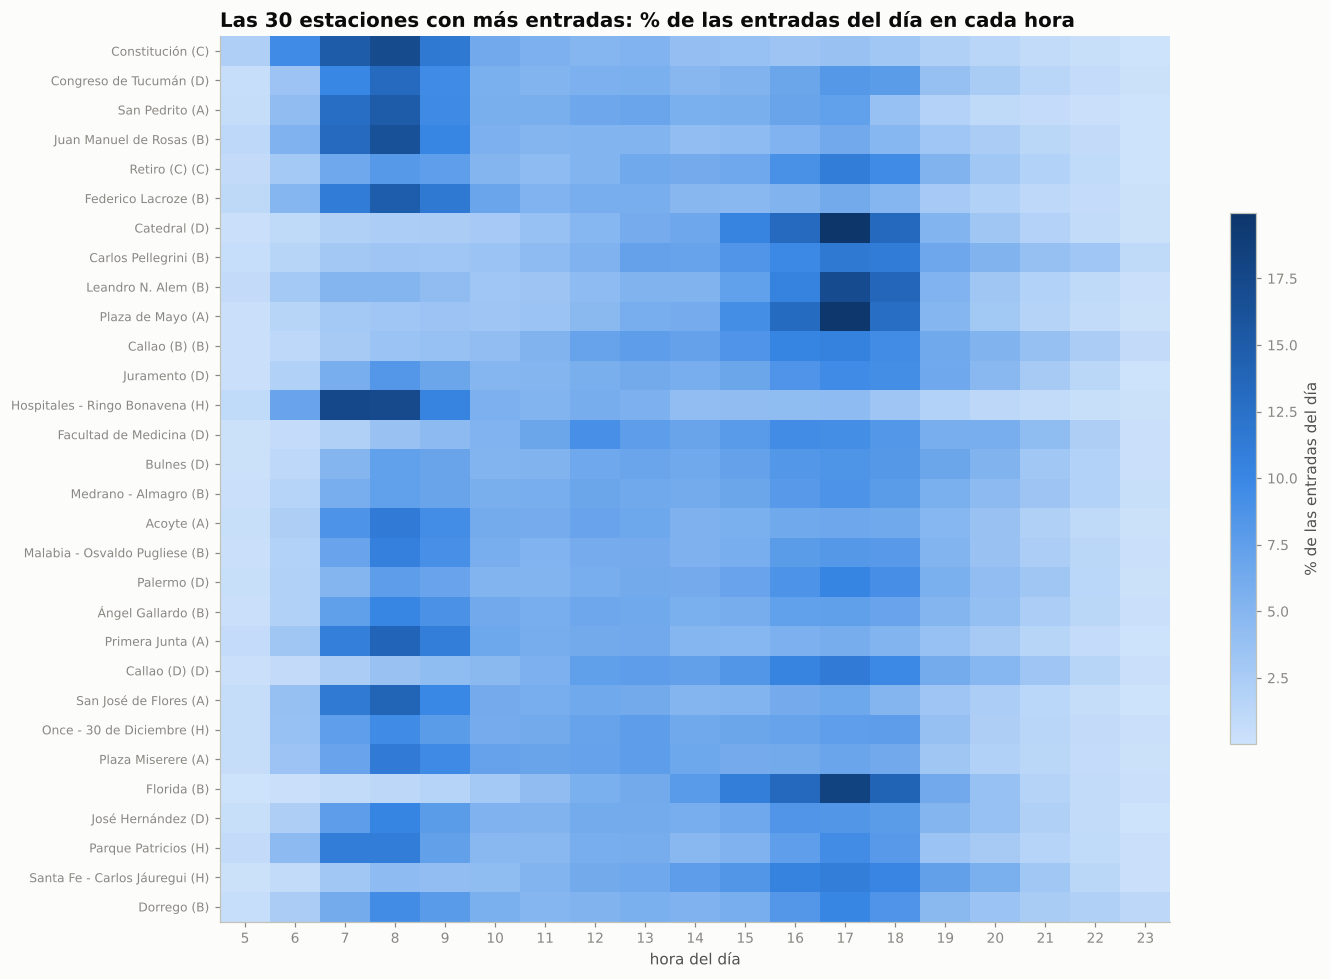

In [3]:
P = ho.matriz_perfiles(largo)
top = largo[largo["tipo_dia"] == "habil"].groupby(["linea", "estacion"])["pasajeros"].sum().sort_values(ascending=False).head(30).index
H = P.loc[top]
fig, ax = plt.subplots(figsize=(13, 9))
im = ax.imshow(H.values * 100, cmap=e.cmap_secuencial(), aspect="auto")
ax.set_xticks(range(len(H.columns)), H.columns); ax.set_yticks(range(len(H)), [f"{est} ({l})" for l, est in H.index], fontsize=8)
ax.grid(False); ax.set_xlabel("hora del día")
ax.set_title("Las 30 estaciones con más entradas: % de las entradas del día en cada hora")
fig.colorbar(im, ax=ax, shrink=0.6, label="% de las entradas del día"); fig.tight_layout()
fig.savefig(FIG / "horario_calor_estaciones.png"); plt.show()


**Lectura.** Cada fila es una estación y cada columna una hora: el color es qué parte de las entradas del día ocurre en
esa hora. Se ven dos dibujos: estaciones que se "encienden" temprano (la gente sale de su casa) y estaciones que se
encienden a la tarde (la gente vuelve del trabajo, típicamente en el centro).

## 3. Agrupamiento de estaciones por la forma de su curva (K-Means)

Cada estación es un vector de 19 valores (la proporción de sus entradas en cada hora, de 5 a 23 h). Al usar
proporciones comparamos la **forma** de la curva y no el volumen. Elegimos k por silueta.

 k  silueta
 2     0.48
 3     0.40
 4     0.41
 5     0.35


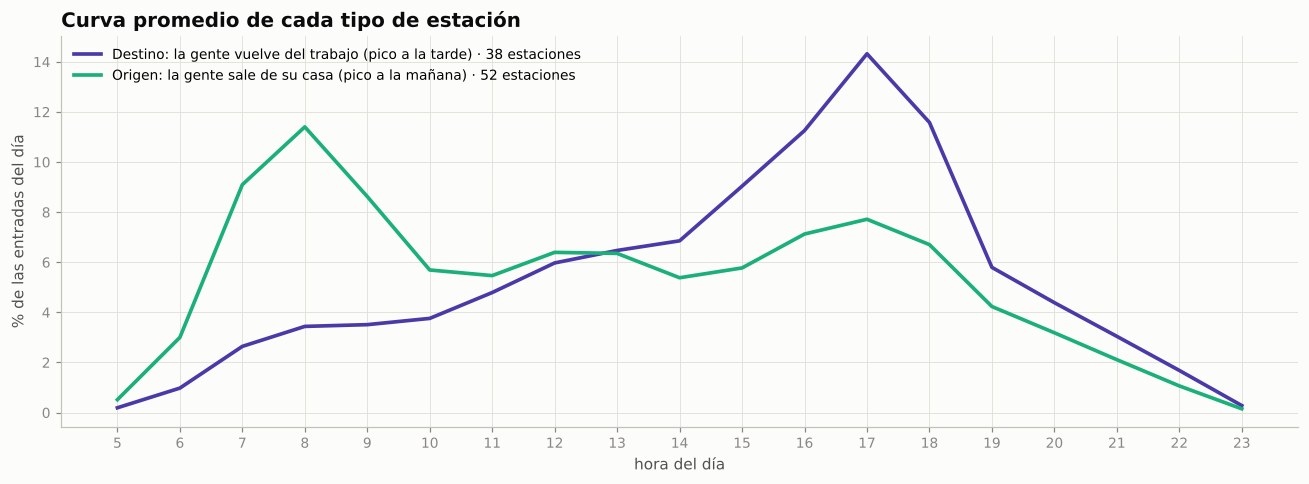

perfil
Origen: la gente sale de su casa (pico a la mañana)       52
Destino: la gente vuelve del trabajo (pico a la tarde)    38
Name: count, dtype: int64

In [4]:
grupos, ks = ho.agrupar_estaciones(P)
print(ks.round(3).to_string(index=False))
medias = P.groupby(grupos).mean()
fig, ax = plt.subplots(figsize=(12, 4.5))
for nombre, color in zip(medias.index, [DESTINO, ORIGEN] if medias.index[0].startswith("Destino") else [ORIGEN, DESTINO]):
    n = (grupos == nombre).sum()
    ax.plot(medias.columns, medias.loc[nombre] * 100, color=color, linewidth=2.4, label=f"{nombre} · {n} estaciones")
ax.set(title="Curva promedio de cada tipo de estación", xlabel="hora del día", ylabel="% de las entradas del día", xticks=range(5, 24))
ax.legend(loc="upper left", fontsize=9); fig.tight_layout(); fig.savefig(FIG / "horario_tipos_estacion.png"); plt.show()
grupos.value_counts()

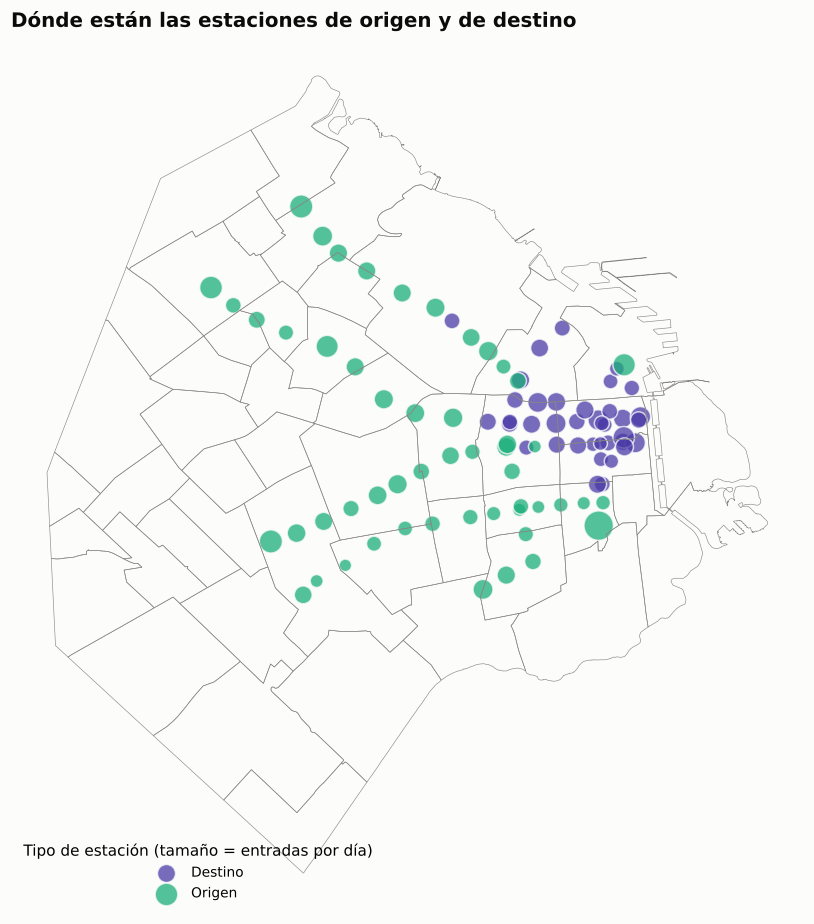

In [5]:
est = pd.read_csv(PROC / "estaciones_subte.csv")
barrios = f.cargar_barrios()
fig, ax = plt.subplots(figsize=(9, 8.5))
barrios.boundary.plot(ax=ax, color=e.TINTA_SUAVE, linewidth=0.4)
for nombre, sub in est.groupby("perfil"):
    color = ORIGEN if nombre.startswith("Origen") else DESTINO
    ax.scatter(sub["lon"], sub["lat"], s=np.sqrt(sub["pax_habil"]) * 1.6, color=color, alpha=0.75, edgecolors=e.FONDO,
               linewidths=1, label=nombre.split(":")[0])
ax.legend(loc="lower left", title="Tipo de estación (tamaño = entradas por día)"); ax.set_axis_off()
ax.set_title("Dónde están las estaciones de origen y de destino")
fig.tight_layout(); fig.savefig(FIG / "mapa_tipos_estacion.png"); plt.show()


**Lectura.** El K-Means separa 2 tipos de estación (la silueta más alta se da con k = 2):
- **Origen: la gente sale de su casa (pico a la mañana)**: 52 estaciones;
- **Destino: la gente vuelve del trabajo (pico a la tarde)**: 38 estaciones.

Las estaciones de destino se concentran en el centro y los corredores de oficinas; las de origen están en los barrios.
Es la misma división de la ciudad que aparece en los tipos de zona del notebook 02, pero obtenida con otra fuente y otra
técnica: un buen chequeo de consistencia.

## 4. ¿Tienen un Link cerca?

In [6]:
col = "dist_link_usada_m"
est["tiene_link"] = est[col] <= f.RADIO_COBERTURA_M
tabla = (est.groupby("perfil").agg(estaciones=("estacion", "count"), con_link=("tiene_link", "sum"),
                                   entradas_dia=("pax_habil", "sum"))
         .assign(pct_con_link=lambda d: d["con_link"] / d["estaciones"]))
manana = largo[(largo["tipo_dia"] == "habil") & largo["hora"].isin(ho.MANANA)].groupby(["linea", "estacion"])["pasajeros"].sum()
est["entradas_manana"] = est.set_index(["linea", "estacion"]).index.map(manana).fillna(0)
print(f"Distancia usada: {'caminando' if 'dist_link_m_red' in est else 'línea recta'}")
display(tabla)
est.loc[~est["tiene_link"], ["linea", "estacion", "perfil", "pax_habil", "entradas_manana", col]].sort_values("pax_habil", ascending=False)

Distancia usada: línea recta


,estaciones,con_link,entradas_dia,pct_con_link
perfil,,,,
Destino: la gente vuelve del trabajo (pico a la tarde),38,38,"252,007.70",1.00
Origen: la gente sale de su casa (pico a la mañana),52,49,"438,933.60",0.94


,linea,estacion,perfil,pax_habil,entradas_manana,dist_link_usada_m
84,H,Inclán-Mezquita Al Ahmad,Origen: la gente sale de su casa (pico a la ma...,"4,069.40","1,361.10",561.92
73,E,Pichincha,Origen: la gente sale de su casa (pico a la ma...,"2,090.30",692.30,535.58
72,E,Medalla Milagrosa,Origen: la gente sale de su casa (pico a la ma...,"1,782.40",766.90,838.91



**Lectura.** Casi todas las estaciones ya tienen un Link a menos de 500 m (medido en línea recta):
87 de 90. Las que no lo tienen son estaciones de **origen**, con 7.942
entradas por día hábil en total (Medalla Milagrosa, Pichincha, Inclán-Mezquita Al Ahmad). El subte, entonces, **no** es donde falta Link: la
gente que viaja ya pasa cerca de un cajero. El faltante está en los barrios, lejos de las estaciones.

## 5. ¿Cambia dónde poner cajeros si sumamos a los pasajeros de la hora pico?

Volvemos a resolver la cobertura máxima exacta con 20 cajeros, pero ahora cada persona que entra al subte en la zona
entre las 6 y las 10 h de un día hábil cuenta igual que un vecino.

In [7]:
import json
res = pd.read_parquet(PROC / "resultados_hex.parquet")
resumen = json.loads((PROC / "resumen.json").read_text(encoding="utf-8"))
metodo = "red" if resumen["metodo_distancia"] == "caminando" else "recta"
import src.red as rp
conj = (rp.conjuntos_red(res, rp.RedPeatonal.desde_archivos(), 500) if metodo == "red" else m.conjuntos_recta(res, 500))
solo_vecinos = m.resolver_exacto(res, 20, conj, m.demanda(res))
con_manana = m.resolver_exacto(res, 20, conj, m.demanda(res, 1.0, "pax_subte_manana"))
comunes = set(solo_vecinos["h3"]) & set(con_manana["h3"])
print(f"Sitios en común: {len(comunes)} de 20")
cambian = con_manana[~con_manana["h3"].isin(comunes)][["orden", "barrio", "comuna", "personas_nuevas", "residentes_nuevos"]]
cambian.assign(pasajeros_manana=lambda d: d["personas_nuevas"] - d["residentes_nuevos"]).round(0)

Sitios en común: 20 de 20


,orden,barrio,comuna,personas_nuevas,residentes_nuevos,pasajeros_manana



**Lectura.** Sumar a los pasajeros de la hora pico de la mañana **no cambia** las ubicaciones óptimas (o las cambia muy
poco): las estaciones ya están cubiertas, así que lo que define dónde poner cajeros son los vecinos sin un Link cerca. Es
una conclusión robusta: no depende de cuánto pesemos a los pasajeros.

## 6. Conclusión


- La demanda de paso tiene horario: **8:00** y **17:00** en día hábil. Un cajero cerca de una estación de origen ve
  su demanda a primera hora; uno en el centro, al final de la tarde. Es un dato útil para la **Gerencia Técnica**:
  programar la carga de efectivo y el mantenimiento **antes** de esos picos (hipótesis a validar con las transacciones
  por hora que Red Link sí tiene).
- Las estaciones de subte ya tienen Link cerca: la oportunidad de cobertura está en los **barrios**, no en el transporte.
- La división origen/destino del subte confirma, con otra fuente, la ciudad de dos velocidades del análisis de zonas.